In [9]:
import cv2
import os
import numpy as np

INPUT_DIR = "dataset"
OUTPUT_DIR = "processed_dataset"
IMG_SIZE = 512

os.makedirs(OUTPUT_DIR, exist_ok=True)

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.medianBlur(img, 5)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    return img

for label in os.listdir(INPUT_DIR):
    in_dir = os.path.join(INPUT_DIR, label)
    out_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(out_dir, exist_ok=True)

    for f in os.listdir(in_dir):
        img_path = os.path.join(in_dir, f)
        processed = preprocess_image(img_path)
        cv2.imwrite(os.path.join(out_dir, f),
                    (processed * 255).astype(np.uint8))

print("✅ Preprocessing completed")


✅ Preprocessing completed


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
import cv2
import numpy as np

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(512, 512, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

model = Model(inputs=base_model.input, outputs=x)

def extract_densenet_features(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    features = model.predict(img, verbose=0)
    return features.flatten()   # 1024 features


In [5]:
from skimage.feature import local_binary_pattern

def extract_lbp_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (512, 512))

    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, 59),
                           density=True)
    return hist


In [6]:
from skimage.feature import graycomatrix, graycoprops

def extract_glcm_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (512, 512))

    glcm = graycomatrix(
        img,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    return np.array([
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0]
    ])


In [3]:
def extract_hybrid_features(img_path):
    f1 = extract_densenet_features(img_path)
    f2 = extract_lbp_features(img_path)
    f3 = extract_glcm_features(img_path)
    return np.concatenate([f1, f2, f3])


Label name	Label ID	Cancer status
Normal	0	❌ Non-cancer
Bengin (Benign)	1	⚠️ Non-cancer (tumor but not cancer)
Malignant	2	✅ Cancer

In [17]:
DATASET_DIR = "processed_dataset"
LABELS = {"Normal": 0, "Bengin": 1, "Malignant": 2}

X = []
y = []

for label_name, label_id in LABELS.items():
    folder = os.path.join(DATASET_DIR, label_name)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        features = extract_hybrid_features(img_path)

        X.append(features)
        y.append(label_id)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1097, 1086)
y shape: (1097,)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [19]:
import random
from deap import base, creator, tools, algorithms
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

NUM_FEATURES = X.shape[1]

# Avoid duplicate creation in Jupyter
if "FitnessMax" not in creator.__dict__:
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat,
                 creator.Individual, toolbox.attr_bool, NUM_FEATURES)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(individual):
    idx = [i for i, bit in enumerate(individual) if bit == 1]
    if len(idx) == 0:
        return 0,

    X_sel = X[:, idx]
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    acc = cross_val_score(clf, X_sel, y, cv=5).mean()

    penalty = len(idx) / NUM_FEATURES
    return acc - 0.1 * penalty,

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.02)
toolbox.register("select", tools.selTournament, tournsize=3)

population = toolbox.population(n=30)

algorithms.eaSimple(
    population,
    toolbox,
    cxpb=0.5,
    mutpb=0.2,
    ngen=25,
    verbose=True
)

best = tools.selBest(population, k=1)[0]
selected_features = [i for i, bit in enumerate(best) if bit == 1]

X_optimized = X[:, selected_features]

print("✅ Selected Features:", len(selected_features))


gen	nevals
0  	30    
1  	19    
2  	14    
3  	21    
4  	23    
5  	16    
6  	21    
7  	23    
8  	15    
9  	19    
10 	21    
11 	16    
12 	16    
13 	24    
14 	20    
15 	19    
16 	21    
17 	18    
18 	17    
19 	15    
20 	17    
21 	20    
22 	19    
23 	19    
24 	19    
25 	15    
✅ Selected Features: 531


In [20]:
y_binary = np.where(y == 2, 1, 0)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_optimized,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)


In [22]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


SVM Accuracy: 1.0
[[107   0]
 [  0 113]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       107
           1       1.00      1.00      1.00       113

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dnn = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

dnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss, acc = dnn.evaluate(X_test, y_test)
print("DNN Accuracy:", acc)


Epoch 1/30


c:\Program Files\Python311\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9272 - loss: 0.1605 - val_accuracy: 0.9886 - val_loss: 0.0186
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9943 - loss: 0.0138 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9971 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 9.8530e-04
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 7.7646e-04 - val_accuracy: 1.0000 - val_loss: 7.4689e-04
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 6.7347e-04
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 5.6138e-04 - val_accuracy: 1.0000 - 

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predict probabilities
y_prob = dnn.predict(X_test)

# Convert probabilities → class labels (0 or 1)
y_pred = (y_prob > 0.5).astype(int).ravel()
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Confusion Matrix:
 [[106   1]
 [  0 113]]


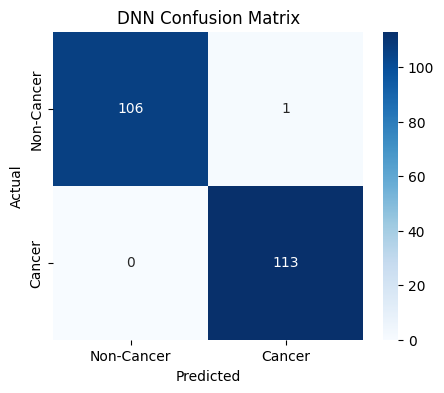

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Cancer", "Cancer"],
            yticklabels=["Non-Cancer", "Cancer"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DNN Confusion Matrix")
plt.show()


In [27]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Cancer", "Cancer"]
))

              precision    recall  f1-score   support

  Non-Cancer       1.00      0.99      1.00       107
      Cancer       0.99      1.00      1.00       113

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



In [29]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)


ROC-AUC Score: 1.0


In [30]:
# Save model
dnn.save("lung_cancer_dnn_model.h5")
print("✅ Model saved successfully")

✅ Model saved successfully


In [31]:
import numpy as np

np.save("selected_features.npy", selected_features)
print("✅ Selected feature indices saved")


✅ Selected feature indices saved


In [32]:
import joblib
joblib.dump(scaler, "feature_scaler.pkl")
print("✅ Feature scaler saved")


✅ Feature scaler saved


In [1]:
import tensorflow as tf
import numpy as np
import joblib

# Load trained model
dnn = tf.keras.models.load_model("lung_cancer_dnn_model.h5")

# Load GA-selected feature indices
selected_features = np.load("selected_features.npy")

# Load scaler
scaler = joblib.load("feature_scaler.pkl")

print("✅ Model and utilities loaded")


✅ Model and utilities loaded


In [7]:
def predict_single_image(img_path):
    # -------- Feature Extraction --------
    features = extract_hybrid_features(img_path)

    # Convert to 2D
    features = features.reshape(1, -1)

    # Scale features
    features = scaler.transform(features)

    # Select GA-optimized features
    features = features[:, selected_features]

    # Predict probability
    prob = dnn.predict(features)[0][0]

    # Class decision
    label = "Cancer" if prob > 0.5 else "Non-Cancer"

    return label, prob
image_path = "dataset/normal/Normal case (2).jpg"

label, confidence = predict_single_image(image_path)

print("Prediction:", label)
print("Confidence:", round(confidence * 100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Prediction: Non-Cancer
Confidence: 30.23 %


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_optimized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dnn_3class = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")   # 3 classes
])

dnn_3class.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dnn_3class.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30


c:\Program Files\Python311\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7946 - loss: 0.5615 - val_accuracy: 0.8977 - val_loss: 0.2388
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9016 - loss: 0.2287 - val_accuracy: 0.9602 - val_loss: 0.1582
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9358 - loss: 0.1609 - val_accuracy: 0.9602 - val_loss: 0.1250
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9686 - loss: 0.1019 - val_accuracy: 0.9830 - val_loss: 0.0905
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9743 - loss: 0.0698 - val_accuracy: 0.9716 - val_loss: 0.0763
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9729 - loss: 0.0785 - val_accuracy: 0.9886 - val_loss: 0.0598
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9886 - loss: 0.0424 - val_accuracy: 0.9830 - val_loss: 0.0477
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9872 - loss: 0.0420 - val_accuracy: 0.9886 - val_loss: 0.0550
Epo

In [39]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predict class probabilities
y_prob = dnn_3class.predict(X_test)

# Convert probabilities → class labels
y_pred = np.argmax(y_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Benign", "Malignant"]
))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Confusion Matrix:
 [[ 83   0   0]
 [  4  20   0]
 [  0   0 113]]
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.98        83
      Benign       1.00      0.83      0.91        24
   Malignant       1.00      1.00      1.00       113

    accuracy                           0.98       220
   macro avg       0.98      0.94      0.96       220
weighted avg       0.98      0.98      0.98       220



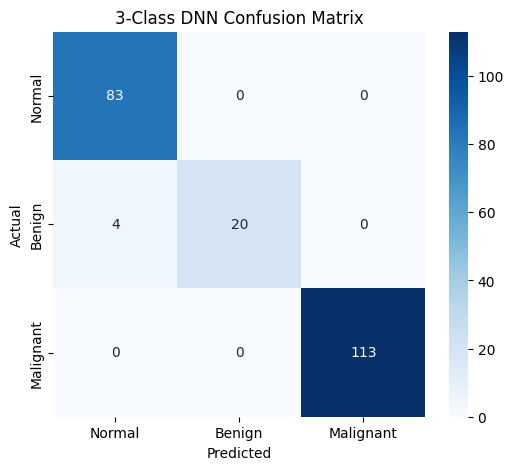

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Benign","Malignant"],
            yticklabels=["Normal","Benign","Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("3-Class DNN Confusion Matrix")
plt.show()

In [41]:
dnn_3class.save("lung_cancer_dnn_3class.h5")
print("✅ 3-class model saved")


✅ 3-class model saved


In [56]:
import tensorflow as tf
import numpy as np
import joblib

# Load trained 3-class DNN model
dnn_3class = tf.keras.models.load_model("lung_cancer_dnn_3class.h5")

# Load GA-selected feature indices
selected_features = np.load("selected_features.npy")

# Load feature scaler
scaler = joblib.load("feature_scaler.pkl")

print("✅ Model, selected features, and scaler loaded")


✅ Model, selected features, and scaler loaded


In [57]:
CLASS_NAMES = ["Normal", "Benign", "Malignant"]

def predict_single_image_3class(img_path):
    # Extract hybrid features
    features = extract_hybrid_features(img_path)
    features = features.reshape(1, -1)

    # Scale
    features = scaler.transform(features)

    # GA feature selection
    features = features[:, selected_features]

    # Predict
    probs = dnn_3class.predict(features)[0]
    pred_class = np.argmax(probs)

    return CLASS_NAMES[pred_class], probs[pred_class]
image_path = "dataset/normal/Normal case (3).jpg"

label, confidence = predict_single_image_3class(image_path)

print("Prediction:", label)
print("Confidence:", round(confidence * 100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: Malignant
Confidence: 98.42 %


In [6]:
!pip install deap

   ---------------------------------------- 0.0/109.7 kB ? eta -:--:--
   ------- ------------------------------- 20.5/109.7 kB 320.0 kB/s eta 0:00:01
   ------------------------- ------------- 71.7/109.7 kB 777.7 kB/s eta 0:00:01
   -------------------------------------- 109.7/109.7 kB 904.3 kB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
